In [1]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
import sys

from pathlib import Path

# Add src folder to sys.path so imports work
sys.path.append(str(Path.cwd().parent / "src"))

## Load the data

In [3]:
from visualization.data_loader import load_data

data = load_data(clean=False)

Data loaded successfully.


In [4]:
COUNTRY_COL = "Entity"
CODE_COL = "Code"
YEAR_COL = "Year"
MILITARY_EXPENDITURE_COL = "Military expenditure"
WORLD_REGION_COL = "World region according to OWID"

## Explore the data

### Look at the first few rows

In [5]:
print(data.head())

        Entity Code  Year  Military expenditure World region according to OWID
0  Afghanistan  AFG  1970            68814760.0                           Asia
1  Afghanistan  AFG  1973            79796820.0                           Asia
2  Afghanistan  AFG  1974            77561210.0                           Asia
3  Afghanistan  AFG  1975            81419624.0                           Asia
4  Afghanistan  AFG  1976           103842290.0                           Asia


### Look at the summary statistics

In [6]:
print(data.describe())

              Year  Military expenditure
count  9029.000000          9.029000e+03
mean   1995.679256          3.141625e+10
std      18.919170          1.541548e+11
min    1949.000000          0.000000e+00
25%    1982.000000          1.535985e+08
50%    1998.000000          1.174800e+09
75%    2011.000000          6.078290e+09
max    2024.000000          2.676514e+12


### Check for missing values

In [7]:
print(data.isnull().sum())

Entity                              0
Code                              667
Year                                0
Military expenditure                0
World region according to OWID    703
dtype: int64


In [8]:
# Unique countries
print("Countries in dataset:", data[COUNTRY_COL].unique())

# Unique years
print("Years range from", data[YEAR_COL].min(), "to", data[YEAR_COL].max())

Countries in dataset: <StringArray>
[           'Afghanistan',         'Africa (SIPRI)',                'Albania',
                'Algeria',       'Americas (SIPRI)',                 'Angola',
              'Argentina',                'Armenia', 'Asia & Oceania (SIPRI)',
              'Australia',
 ...
                'Uruguay',             'Uzbekistan',              'Venezuela',
                'Vietnam', 'Western Europe (SIPRI)',                  'World',
                  'Yemen',    'Yemen Arab Republic',                 'Zambia',
               'Zimbabwe']
Length: 187, dtype: str
Years range from 1949 to 2024


### Top spending countries

In [9]:
year = 2022
top_country = data[data[YEAR_COL] == year].sort_values(MILITARY_EXPENDITURE_COL, ascending=False).head(5)
print(f"Top 5 military spending countries in {year}:\n", top_country[[COUNTRY_COL,MILITARY_EXPENDITURE_COL]])

Top 5 military spending countries in 2022:
                       Entity  Military expenditure
8922                   World          2.294524e+12
187         Americas (SIPRI)          9.871045e+11
6127   North America (SIPRI)          9.217192e+11
8693           United States          8.961212e+11
369   Asia & Oceania (SIPRI)          5.666997e+11


## Problem 1: Does data contains duplicates?

In [10]:
def plot_sipri_europe_regions(data: pd.DataFrame, year: int):

    # Filter year
    data_year = data[data["Year"] == year]

    regions = [
        "Central Europe (SIPRI)",
        "Western Europe (SIPRI)",
        "Eastern Europe (SIPRI)"
    ]

    # Get regional totals
    region_data = (
        data_year[data_year["Entity"].isin(regions)]
        .groupby("Entity")["Military expenditure"]
        .sum()
        .reindex(regions)
    )

    # Europe total
    europe_total = data_year[
        data_year["Entity"] == "Europe (SIPRI)"
    ]["Military expenditure"].sum()

    # Sum of the three regions
    regions_sum = region_data.sum()

    # Print values
    print(f"\nMilitary expenditure in {year}")
    print("-" * 40)
    for region, value in region_data.items():
        print(f"{region}: {value:,.0f}")
    print("-" * 40)
    print(f"Sum of 3 regions: {regions_sum:,.0f}")
    print(f"Europe (SIPRI):  {europe_total:,.0f}")
    print(f"Difference:      {abs(europe_total - regions_sum):,.0f}")

    # Plot
    fig, ax = plt.subplots(figsize=(10,5))

    # Europe total bar
    ax.barh("Europe (SIPRI)", europe_total, color="darkblue", label="Europe total")

    # Stacked regional bar
    colors = ["#6baed6", "#74c476", "#fd8d3c"]
    left = 0

    for region, color in zip(region_data.index, colors):
        value = region_data.loc[region]
        ax.barh("Regional breakdown", value, left=left, color=color, label=region)
        left += value

    ax.set_xlabel("Military Expenditure (USD)")
    ax.set_title(f"SIPRI Europe Regions vs Europe Total ({year})")

    ax.legend(bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.show()


Military expenditure in 2023
----------------------------------------
Central Europe (SIPRI): 55,724,446,000
Western Europe (SIPRI): 344,571,840,000
Eastern Europe (SIPRI): 181,181,660,000
----------------------------------------
Sum of 3 regions: 581,477,946,000
Europe (SIPRI):  581,478,000,000
Difference:      54,000


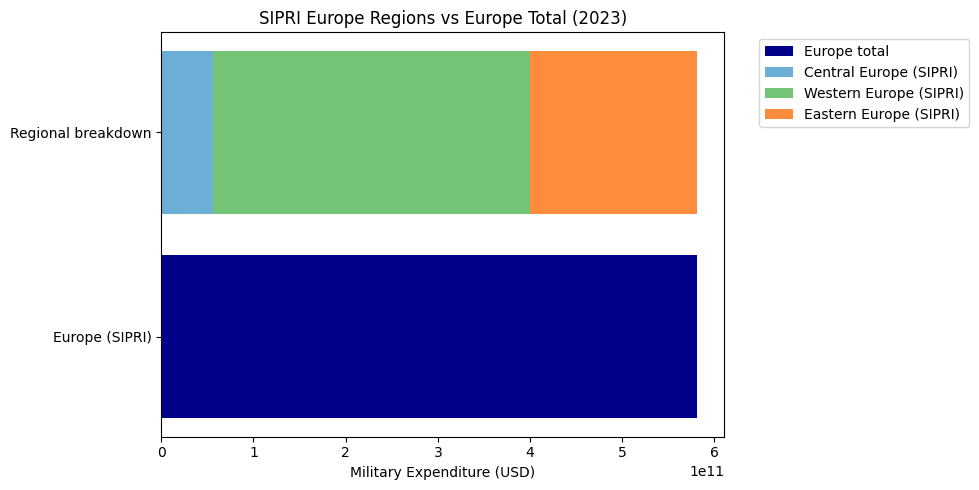

In [11]:
plot_sipri_europe_regions(data, 2023)

## Problem 2: World entries aren't equal to the sum of all countries entries

In [12]:
def compare_sum_vs_world(data: pd.DataFrame, year: int, include_sipri: bool = False):
    """
    Sum all entities in a given year that do NOT contain '(SIPRI)'
    and compare the result with 'World'.
    """

    # Filter year
    data_year = data[data[YEAR_COL] == year]

    # Entities without "(SIPRI)"
    non_sipri = data_year[
        ~data_year[COUNTRY_COL].str.contains(r"\(SIPRI\)", na=False)
    ] if not include_sipri else data_year

    # Remove "World" from the sum
    non_sipri = non_sipri[non_sipri[COUNTRY_COL] != "World"]

    # Sum of all countries
    countries_sum = non_sipri[MILITARY_EXPENDITURE_COL].sum()

    # World value
    world_value = data_year[
        data_year[COUNTRY_COL] == "World"
    ][MILITARY_EXPENDITURE_COL].sum()

    # Print results
    print(f"\nMilitary expenditure comparison for {year}")
    print("-" * 40)
    print(f"Sum of all countries: {countries_sum:,.0f}")
    print(f"World total:          {world_value:,.0f}")
    print(f"Difference:           {abs(world_value - countries_sum):,.0f}")

    # Plot
    fig, ax = plt.subplots(figsize=(8,4))

    labels = ["Sum of countries", "World"]
    values = [countries_sum, world_value]
    colors = ["steelblue", "darkred"]

    ax.barh(labels, values, color=colors)

    ax.set_xlabel("Military Expenditure (USD)")
    ax.set_title(f"World vs Sum of Countries ({year})")

    plt.tight_layout()
    plt.show()


Military expenditure comparison for 2024
----------------------------------------
Sum of all countries: 2,600,795,449,582
World total:          2,676,513,800,000
Difference:           75,718,350,418


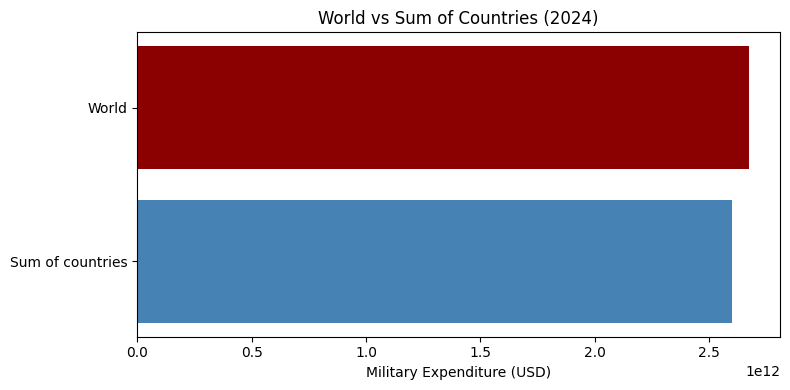

In [13]:
compare_sum_vs_world(
    data,
    2024, 
    include_sipri=False)

## Possible explorative visualizations

### For 1 country: evolution over time

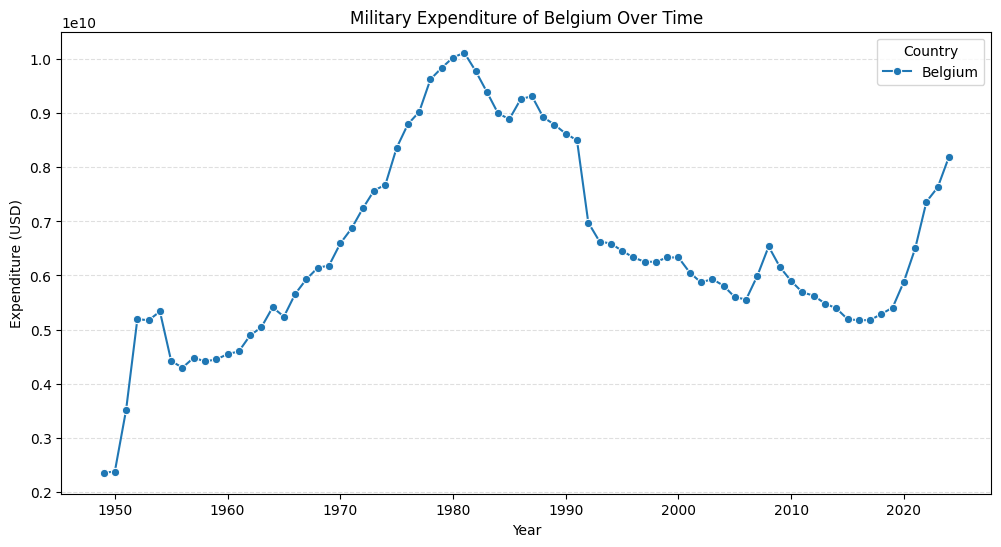

In [25]:
from visualization.data_loader import get_data_for_countries

countries = ['Belgium']  # add more if present in your data
subset = get_data_for_countries(data, countries)

plt.figure(figsize=(12,6))
sns.lineplot(data=subset, x='Year', y=MILITARY_EXPENDITURE_COL, hue=COUNTRY_COL, marker='o')
plt.title(f"Military Expenditure of {countries[0]} Over Time")
plt.ylabel("Expenditure (USD)")
plt.xlabel("Year")
plt.legend(title="Country")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### For multiple countries

In [16]:
def plot_year_horizontal_bar(data: pd.DataFrame, year: int, countries: list = None):
    """
    Plot a horizontal bar chart of military expenditure for a given year.
    
    Parameters:
    - data: pd.DataFrame, the military spending dataset
    - year: int, the year to visualize
    - countries: list of country names to include; if None, include all
    """
    # Filter by year
    data_year = data[data[YEAR_COL] == year]
    
    # Filter by countries if provided
    if countries is not None:
        data_year = data_year[data_year[COUNTRY_COL].isin(countries)]

    # Remove SIPRI aggregates if not included
    data_year = data_year[
        ~data_year[COUNTRY_COL].str.contains(r"\(SIPRI\)", na=False)
    ]

    # Remove the "World" aggregate if present
    data_year = data_year[data_year[COUNTRY_COL] != 'World']

    # Remove the entries with military expenditure of 0 or NaN to focus on actual spenders
    data_year = data_year[data_year[MILITARY_EXPENDITURE_COL] > 0]
    
    if data_year.empty:
        print(f"No data available for year {year} with the selected countries.")
        return
    
    # Sort by expenditure (ascending for horizontal bar)
    data_year = data_year.sort_values(MILITARY_EXPENDITURE_COL, ascending=True)
    
    # Plot
    # Set figure size depending on number of countries to ensure readability
    plt.figure(figsize=(10, max(3, len(data_year) * 0.15)))
    sns.barplot(
        data=data_year,
        x=MILITARY_EXPENDITURE_COL,
        y=COUNTRY_COL,
    )
    plt.title(f"Military Expenditure by Country in {year}", fontsize=16)
    plt.xlabel("Expenditure (USD)")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

**Problem** with plotting all countries using a bar chart: 
if 1 country is a lot higher than others, you can't compare the lower spending countries anymore

sol: use a different type of graph

In [ ]:
year = 2024
plot_year_horizontal_bar(data, year)

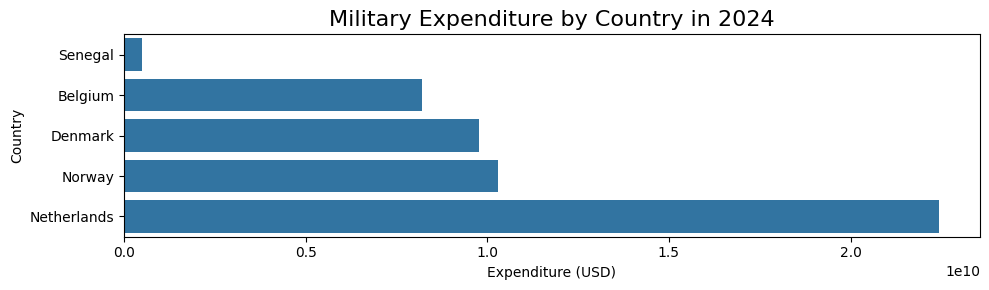

In [18]:
year = 2024
countries = ['Senegal', 'Belgium', 'Netherlands', 'Denmark', 'Norway']
plot_year_horizontal_bar(data, year, countries)

## other idea: slope graph

between 2 years, show the increase/decrease of spending

## Possible "story" visualization

### 1. **Story:** NAVO countries can defend themselfs against Russia withour help of US

1 bar for Russia
1 bar for all countries of NATO + at the end (optinally select/deselect) the bar for US

In [19]:
NATO_countries = [
    "Albania",
    "Belgium",
    "Bulgaria",
    "Canada",
    "Croatia",
    "Czechia",
    "Denmark",
    "Estonia",
    "Finland",
    "France",
    "Germany",
    "Greece",
    "Hungary",
    "Iceland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Montenegro",
    "Netherlands",
    "North Macedonia",
    "Norway",
    "Poland",
    "Portugal",
    "Romania",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "Turkey",
    "United Kingdom"
]

In [20]:
def plot_russia_vs_eu_stacked(data: pd.DataFrame, year: int, include_us: bool = False):
    """
    Plot Russia vs EU (+ optional US) for a given year as horizontal bars:
    - Russia is a single solid color
    - EU countries stacked with different colors
    - US stacked last if included
    """
    # Filter data for the year
    data_year = data[data[YEAR_COL] == year]
    
    # Russia's expenditure
    russia_exp = data_year[data_year[COUNTRY_COL] == 'Russia'][MILITARY_EXPENDITURE_COL].sum()
    
    # Get NATO countries dynamically, exclude Russia
    NATO_data = data_year[data_year[COUNTRY_COL].isin(NATO_countries)].copy()

    # Optionally include US
    if include_us:
        us_data = data_year[data_year[COUNTRY_COL] == 'United States'].copy()
        NATO_data = pd.concat([NATO_data, us_data], ignore_index=True)
    
    if NATO_data.empty:
        print("No NATO/US data available for this year.")
        return
    
    # Sort: NATO first, US last if included
    if include_us:
        NATO_data['sort_order'] = NATO_data[COUNTRY_COL].apply(lambda x: 1 if x == 'United States' else 0)
        NATO_data = NATO_data.sort_values(['sort_order', MILITARY_EXPENDITURE_COL], ascending=[True, False])
    else:
        NATO_data = NATO_data.sort_values(MILITARY_EXPENDITURE_COL, ascending=False)
    
    # Generate a moderately saturated color palette
    n_colors = len(NATO_data)
    colors = sns.color_palette("tab20", n_colors)
    
    # Plot
    _, ax = plt.subplots(figsize=(10, 3))
    
    # Russia bar
    ax.barh('Russia', russia_exp, color='crimson', label='Russia')
    
    # NATO (+ US) stacked bar
    left = 0
    for i, row in enumerate(NATO_data.itertuples()):
        if row.Entity == 'United States':
            ax.barh('NAVO' + (' + US' if include_us else ''),
                    row._4,
                    left=left,
                    color='gray',
                    alpha=0.2,
                    hatch='//',
                    label='United States')
        else:
            ax.barh('NAVO' + (' + US' if include_us else ''),
                    row._4,
                    left=left,
                    color=colors[0],
                    #label=row.Entity
                    )
        left += row._4
    
    ax.set_xlabel("Military Expenditure (USD)")
    ax.set_title(f"Russia vs NATO{' + US' if include_us else ''} in {year}")
    
    # Sort legend alphabetically
    handles, labels = ax.get_legend_handles_labels()
    # Combine and sort by label
    sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0])
    sorted_labels, sorted_handles = zip(*sorted_pairs)
    ax.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()

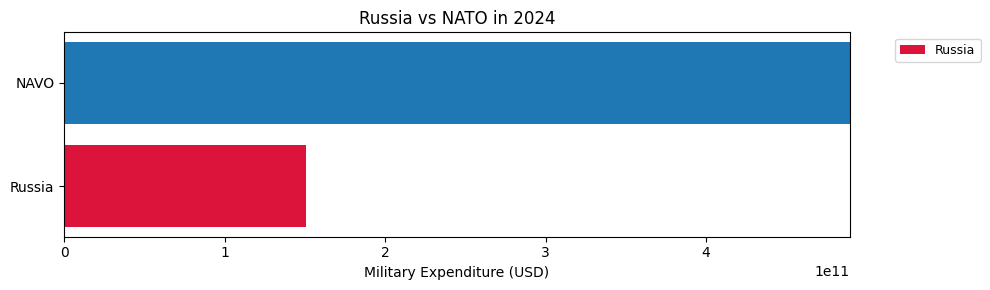

In [21]:
plot_russia_vs_eu_stacked(data, year=2024, include_us=False)

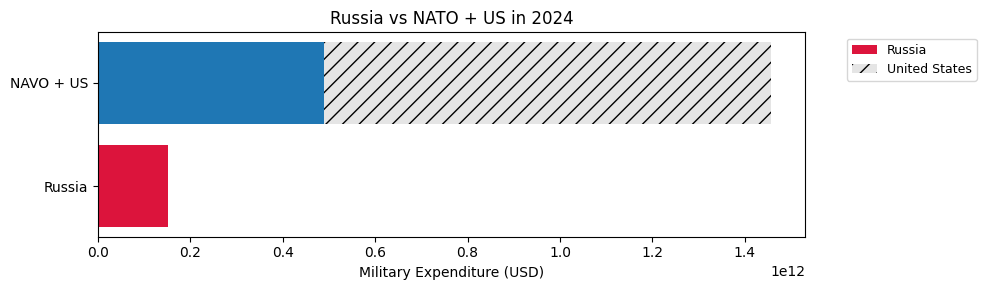

In [22]:
plot_russia_vs_eu_stacked(data, year=2024, include_us=True)

### 2. **Story:** Bekijken of Belgie nog niet genoeg uitgeven aan militaire doeleinden voor NAVO doelstellingen

daarvoor extra info nodig, hoeveel Belgie moet uitgeven aan militaire doeleinden om aan NAVO voorwaarden te voldoen.

### 4. **Story:** Bekijk de evolutie in uitgave van oekraine: gigantische stijging vanaf start oorlog met Rusland

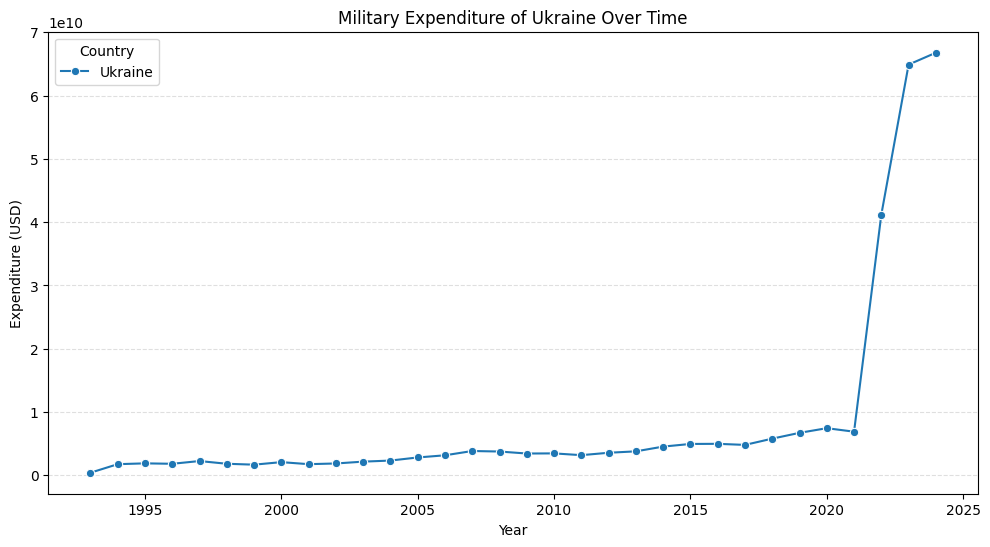

In [24]:
from visualization.data_loader import get_data_for_countries

countries = ['Ukraine']  # add more if present in your data
subset = get_data_for_countries(data, countries)

plt.figure(figsize=(12,6))
sns.lineplot(data=subset, x='Year', y=MILITARY_EXPENDITURE_COL, hue=COUNTRY_COL, marker='o')
plt.title(f"Military Expenditure of {countries[0]} Over Time")
plt.ylabel("Expenditure (USD)")
plt.xlabel("Year")
plt.legend(title="Country")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### 4. **Story:** Vergelijk de uitgaven van Rusland en oekraine tijdens de oorlog

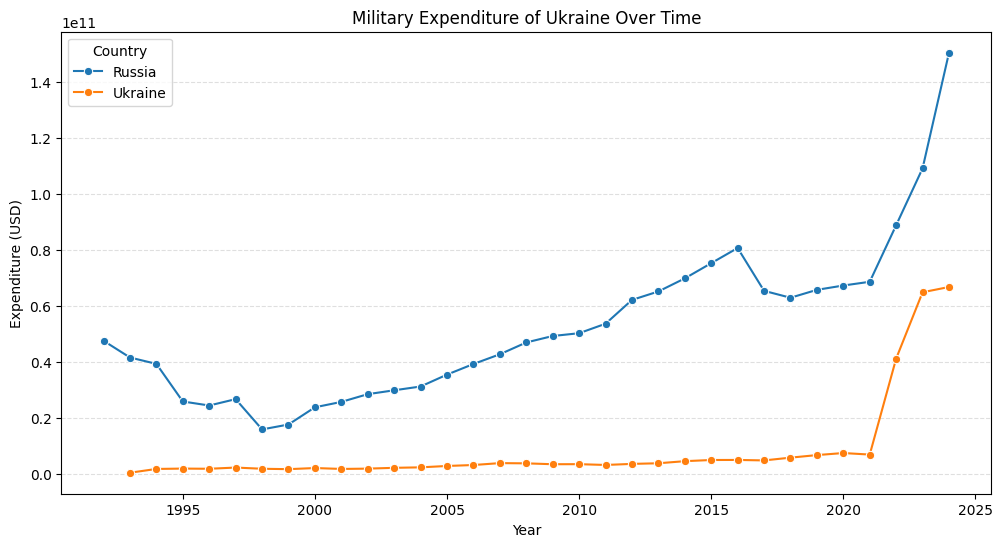

In [35]:
from visualization.data_loader import get_data_for_countries

countries = ['Ukraine', 'Russia']  # add more if present in your data
subset = get_data_for_countries(data, countries)

# only data from 2020 onwards
#subset = subset[subset[YEAR_COL] >= 2020]

plt.figure(figsize=(12,6))
sns.lineplot(data=subset, x='Year', y=MILITARY_EXPENDITURE_COL, hue=COUNTRY_COL, marker='o')
plt.title(f"Military Expenditure of {countries[0]} Over Time")
plt.ylabel("Expenditure (USD)")
plt.xlabel("Year")
plt.legend(title="Country")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()